In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = '/content/drive/MyDrive/LeafGAN_Project'

print("📁 Contents of LeafGAN_Project folder:")
print(os.listdir(base_path))

📁 Contents of LeafGAN_Project folder:
['wilted', 'healthy']


In [ ]:
# ✅ Step 1: Import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# ✅ Step 3: Define ImageDataGenerators

# Without augmentation (only rescale pixel values)
plain_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# With classical augmentation (rotate, shift, brightness, etc.)
aug_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.8, 1.2),
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [ ]:
# ✅ Step 4: Load training and validation data

# Plain (no augmentation)
train_plain = plain_gen.flow_from_directory(
    base_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_plain = plain_gen.flow_from_directory(
    base_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# With augmentation
train_aug = aug_gen.flow_from_directory(
    base_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_aug = aug_gen.flow_from_directory(
    base_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


Found 1428 images belonging to 2 classes.
Found 356 images belonging to 2 classes.
Found 1428 images belonging to 2 classes.
Found 356 images belonging to 2 classes.


# MobileNet + original photo (without aug) +fine-tuned

In [ ]:
# ✅ Step 1: Import necessary libraries
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ✅ Step 2: Load base model (MobileNetV2 without top layers)
base_model = MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,          # We're going to add our own classification head
    weights='imagenet'          # Use pretrained weights
)

# ✅ Step 3: Freeze base model layers
base_model.trainable = False

<ipython-input-7-952c280ca5bf>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ✅ Step 4: Add custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification (healthy vs wilted)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

# ✅ Step 5: Compile the model
model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

# ✅ Optional: early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# ✅ Step 6: Train the model using augmented data
# (You already have train_aug and val_aug from ImageDataGenerator)

history_mobilenet = model_mobilenet.fit(
    train_plain,
    validation_data=val_aug,
    epochs=50,
    callbacks=[early_stop]
    '
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 318s 7s/step - accuracy: 0.5124 - loss: 0.7707 - val_accuracy: 0.7612 - val_loss: 0.5161
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step - accuracy: 0.7314 - loss: 0.5305 - val_accuracy: 0.8090 - val_loss: 0.4569
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.7931 - loss: 0.4614 - val_accuracy: 0.7809 - val_loss: 0.4411
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.8176 - loss: 0.4224 - val_accuracy: 0.8230 - val_loss: 0.4048
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.8304 - loss: 0.3902 - val_accuracy: 0.8146 - val_loss: 0.4051
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.8370 - loss: 0.3733 - val_accuracy: 0.8118 - val_loss: 0.4068
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.8725 - loss: 0.3200 - val_accuracy: 0.7949 - val_loss: 0.4215
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - accuracy: 0.8779 - loss: 0.3164 - val_accura

In [ ]:

# 5. Размораживаем верхние 30 слоёв для fine-tuning
for layer in base_model.layers[-30:]:
    layer.trainable = True

# 6. Компилируем заново с меньшим learning rate
model_mobilenet.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

# 7. Дообучаем модель (fine-tuning)
history_mobilenet_fine = model_mobilenet.fit(
    train_plain,
    validation_data=val_plain,
    epochs=50,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 315ms/step - accuracy: 0.8426 - loss: 0.3527 - val_accuracy: 0.8118 - val_loss: 0.4222
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9130 - loss: 0.2750 - val_accuracy: 0.7978 - val_loss: 0.4827
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.8715 - loss: 0.2983 - val_accuracy: 0.7837 - val_loss: 0.5032
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9093 - loss: 0.2371 - val_accuracy: 0.7753 - val_loss: 0.5249


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_classification_metrics(y_true, y_pred):
    """
    Calculates and prints classification metrics: Accuracy, F1-score, Precision, and Recall.
    Designed for binary classification (e.g., sigmoid output).
    """
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    print(f"✅ Accuracy: {acc:.4f}")
    print(f"🎯 F1-score: {f1:.4f}")
    print(f"🔍 Precision: {precision:.4f}")
    print(f"📥 Recall: {recall:.4f}")

    return acc, f1, precision, recall

In [ ]:
# MobileNetV2: predict on validation set
y_pred = model_mobilenet.predict(val_plain)  # val_aug is your validation ImageDataGenerator
y_pred = (y_pred > 0.5).astype(int)  # convert sigmoid probabilities to binary class (0 or 1)
y_true = val_plain.classes  # true labels from the generator

# Вывод Accuracy, F1 и др.
acc1, f1_1, _, _ = evaluate_classification_metrics(y_true, y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step
✅ Accuracy: 0.8118
🎯 F1-score: 0.7744
🔍 Precision: 0.9664
📥 Recall: 0.6461


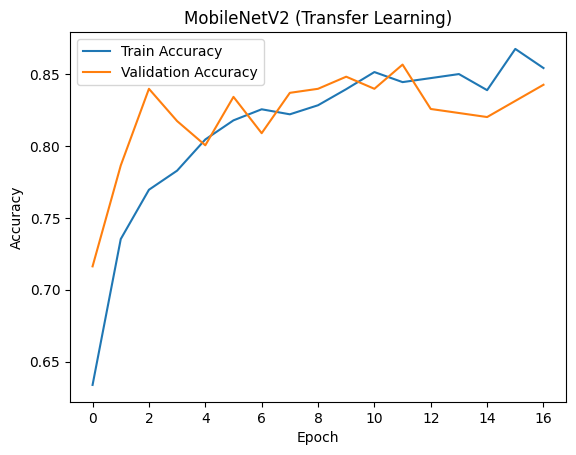

In [ ]:
# ✅ Step 7: Plot results
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history_mobilenet, "MobileNetV2 (Transfer Learning)")

# MobileNet with data ug + fine-tuning

In [ ]:
# ✅ Step 1: Import necessary libraries
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ✅ Step 2: Load base model (MobileNetV2 without top layers)
base_model = MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,          # We're going to add our own classification head
    weights='imagenet'          # Use pretrained weights
)

# ✅ Step 3: Freeze base model layers
base_model.trainable = False


<ipython-input-17-952c280ca5bf>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [ ]:
# ✅ Step 4: Add custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification (healthy vs wilted)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

# ✅ Step 5: Compile the model
model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

# ✅ Optional: early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# ✅ Step 6: Train the model using augmented data
# (You already have train_aug and val_aug from ImageDataGenerator)

history_mobilenet = model_mobilenet.fit(
    train_aug,
    validation_data=val_aug,
    epochs=50,
    callbacks=[early_stop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 271s 6s/step - accuracy: 0.5790 - loss: 0.7270 - val_accuracy: 0.7163 - val_loss: 0.5323
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 663ms/step - accuracy: 0.7383 - loss: 0.5375 - val_accuracy: 0.7865 - val_loss: 0.4601
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 669ms/step - accuracy: 0.7601 - loss: 0.5055 - val_accuracy: 0.8399 - val_loss: 0.4107
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 670ms/step - accuracy: 0.8022 - loss: 0.4354 - val_accuracy: 0.8174 - val_loss: 0.4107
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 664ms/step - accuracy: 0.8119 - loss: 0.4423 - val_accuracy: 0.8006 - val_loss: 0.4118
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 666ms/step - accuracy: 0.8009 - loss: 0.4245 - val_accuracy: 0.8343 - val_loss: 0.3830
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 657ms/step - accuracy: 0.8277 - loss: 0.3851 - val_accuracy: 0.8090 - val_loss: 0.3877
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 667ms/step - accuracy: 0.7993 - loss: 0.4246 - val_accura

In [ ]:

# 5. Размораживаем верхние 30 слоёв для fine-tuning
for layer in base_model.layers[-30:]:
    layer.trainable = True

# 6. Компилируем заново с меньшим learning rate
model_mobilenet.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

# 7. Дообучаем модель (fine-tuning)
history_mobilenet_fine = model_mobilenet.fit(
    train_aug,
    validation_data=val_aug,
    epochs=50,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 56s 890ms/step - accuracy: 0.7944 - loss: 0.4315 - val_accuracy: 0.8371 - val_loss: 0.3501
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 669ms/step - accuracy: 0.8506 - loss: 0.3516 - val_accuracy: 0.8146 - val_loss: 0.4294
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 664ms/step - accuracy: 0.8482 - loss: 0.3450 - val_accuracy: 0.7949 - val_loss: 0.4673
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 671ms/step - accuracy: 0.8575 - loss: 0.3315 - val_accuracy: 0.8006 - val_loss: 0.4635


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_classification_metrics(y_true, y_pred):
    """
    Calculates and prints classification metrics: Accuracy, F1-score, Precision, and Recall.
    Designed for binary classification (e.g., sigmoid output).
    """
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    print(f"✅ Accuracy: {acc:.4f}")
    print(f"🎯 F1-score: {f1:.4f}")
    print(f"🔍 Precision: {precision:.4f}")
    print(f"📥 Recall: {recall:.4f}")

    return acc, f1, precision, recall

In [ ]:
# MobileNetV2: predict on validation set
y_pred = model_mobilenet.predict(val_aug)  # val_aug is your validation ImageDataGenerator
y_pred = (y_pred > 0.5).astype(int)  # convert sigmoid probabilities to binary class (0 or 1)
y_true = val_aug.classes  # true labels from the generator

# Вывод Accuracy, F1 и др.
acc1, f1_1, _, _ = evaluate_classification_metrics(y_true, y_pred)


12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 496ms/step
✅ Accuracy: 0.8399
🎯 F1-score: 0.8246
🔍 Precision: 0.9116
📥 Recall: 0.7528


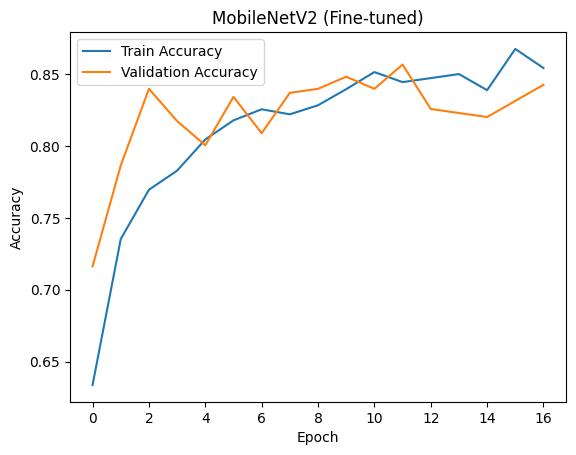

In [ ]:
# ✅ Step 7: Plot results
def plot_history(history_mobilenet_fine, title):
    plt.plot(history_mobilenet_fine.history['accuracy'], label='Train Accuracy')
    plt.plot(history_mobilenet_fine.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history_mobilenet, "MobileNetV2 (Fine-tuned)")

# Resnet + original dataset

In [ ]:
# ✅ Step 1: Import libraries
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ✅ Step 2: Load pretrained ResNet50 base (without top layers)
base_model = ResNet50(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)

# ✅ Step 3: Freeze base layers
base_model.trainable = False


In [ ]:
# ✅ Step 4: Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)


In [ ]:
# ✅ Step 5: Compile the model
model_resnet.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])


In [ ]:
# ✅ Step 6: Fit the model (using augmented data you already have)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_resnet = model_resnet.fit(
    train_plain,
    validation_data=val_aug,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4977 - loss: 0.7289

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.4977 - loss: 0.7288 - val_accuracy: 0.6124 - val_loss: 0.6819
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 255ms/step - accuracy: 0.5141 - loss: 0.7072 - val_accuracy: 0.5169 - val_loss: 0.6843
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 251ms/step - accuracy: 0.5124 - loss: 0.7122 - val_accuracy: 0.5646 - val_loss: 0.6774
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 249ms/step - accuracy: 0.5412 - loss: 0.6976 - val_accuracy: 0.5281 - val_loss: 0.6828
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step - accuracy: 0.5180 - loss: 0.7010 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 252ms/step - accuracy: 0.5062 - loss: 0.7082 - val_accuracy: 0.6376 - val_loss: 0.6773
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 251ms/step - accuracy: 0.5452 - loss: 0.6866 - val_accuracy: 0.5000 - val_loss: 0.6871
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - accuracy: 0.5534 - loss: 0.6864 - val_accuracy: 0.5843 

In [ ]:
# ✅ Step 7: Fine-tuning — unfreeze top layers of ResNet
for layer in base_model.layers[-30:]:
    layer.trainable = True  # Unfreeze the last 30 layers

# 🔁 Re-compile with a lower learning rate
model_resnet.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# ✅ Step 8: Fine-tune the model
history_resnet_fine = model_resnet.fit(
    train_aug,
    validation_data=val_aug,
    epochs=50,
    callbacks=[early_stop]
)


In [ ]:
#  predict on validation set
y_pred = model_resnet.predict(val_plain)  # val_pl is your validation ImageDataGenerator
y_pred = (y_pred > 0.5).astype(int)  # convert sigmoid probabilities to binary class (0 or 1)
y_true = val_plain.classes  # true labels from the generator

# Вывод Accuracy, F1 и др.
acc1, f1_1, _, _ = evaluate_classification_metrics(y_true, y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 422ms/step
✅ Accuracy: 0.6236
🎯 F1-score: 0.6278
🔍 Precision: 0.6209
📥 Recall: 0.6348


#  DenseNET + original


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ✅ Load DenseNet121 without the top classification layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# ✅ Freeze all layers in the base model initially
base_model.trainable = False

# ✅ Build the full model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Use 1 unit for binary classification
])

# ✅ Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ✅ Set up callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ✅ Train the model
history = model.fit(
    train_plain,
    validation_data=val_plain,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 623ms/step - accuracy: 0.5462 - loss: 0.8596 - val_accuracy: 0.6264 - val_loss: 0.6430
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.5370 - loss: 0.7576 - val_accuracy: 0.6657 - val_loss: 0.6185
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.5812 - loss: 0.7467 - val_accuracy: 0.6994 - val_loss: 0.6056
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.6214 - loss: 0.6830 - val_accuracy: 0.7107 - val_loss: 0.5931
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.5995 - loss: 0.6727 - val_accuracy: 0.7163 - val_loss: 0.5822
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.6258 - loss: 0.6516 - val_accuracy: 0.7247 - val_loss: 0.5706
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.6421 - loss: 0.6531 - val_accuracy: 0.7528 - val_loss: 0.5628
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.6278 - loss: 0.6505 - val_accuracy: 0

In [ ]:
# ✅ Step 1: Unfreeze the base model
base_model.trainable = True

# ✅ Step 2: Freeze all layers except the last N (for example, last 30)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# ✅ Step 3: Recompile with a smaller learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ✅ Step 4: Fine-tune the model (continue training)
fine_tune_history = model.fit(
    train_plain,
    validation_data=val_plain,
    epochs=50,
    callbacks=[early_stop],
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 58s 698ms/step - accuracy: 0.7485 - loss: 0.4894 - val_accuracy: 0.8427 - val_loss: 0.4169
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.7945 - loss: 0.4592 - val_accuracy: 0.8483 - val_loss: 0.4096
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.8205 - loss: 0.4157 - val_accuracy: 0.8455 - val_loss: 0.4016
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.7797 - loss: 0.4627 - val_accuracy: 0.8539 - val_loss: 0.3935
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.8121 - loss: 0.4028 - val_accuracy: 0.8539 - val_loss: 0.3860
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.8232 - loss: 0.3889 - val_accuracy: 0.8567 - val_loss: 0.3790
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.8158 - loss: 0.4095 - val_accuracy: 0.8652 - val_loss: 0.3727
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.8296 - loss: 0.3766 - val_accuracy: 0

In [ ]:
  #predict on validation set
y_pred = model.predict(val_plain)  # val_pl is your validation ImageDataGenerator
y_pred = (y_pred > 0.5).astype(int)  # convert sigmoid probabilities to binary class (0 or 1)
y_true = val_plain.classes  # true labels from the generator

# Вывод Accuracy, F1 и др.
acc1, f1_1, _, _ = evaluate_classification_metrics(y_true, y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
✅ Accuracy: 0.8989
🎯 F1-score: 0.8966
🔍 Precision: 0.9176
📥 Recall: 0.8764


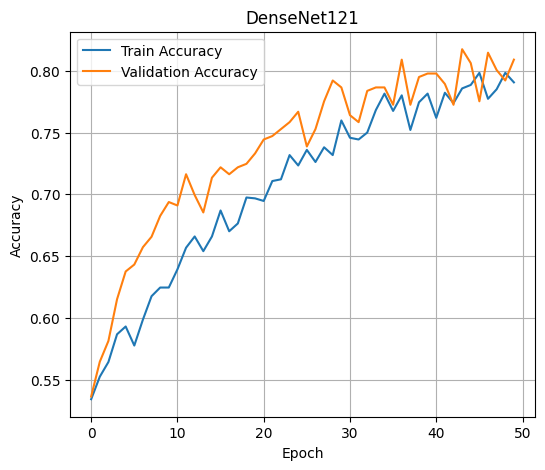

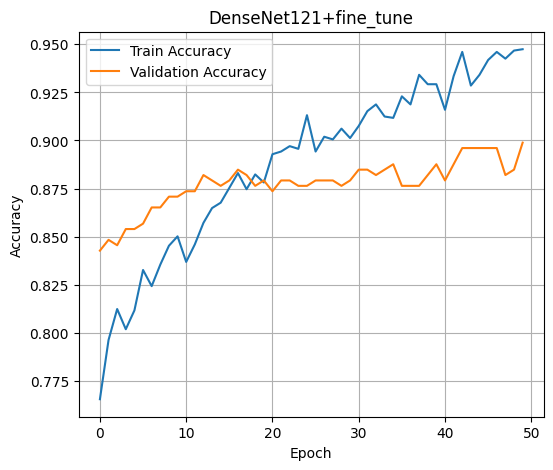

In [ ]:
import matplotlib.pyplot as plt

def plot_accuracy_only(history, model_name="DenseNet121"):
    plt.figure(figsize=(6, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_accuracy_only(history, "DenseNet121")
plot_accuracy_only(fine_tune_history, "DenseNet121+fine_tune")



# DenseNet with augm

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ✅ Load DenseNet121 without the top classification layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# ✅ Freeze all layers in the base model initially
base_model.trainable = False

# ✅ Build the full model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Use 1 unit for binary classification
])

# ✅ Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ✅ Set up callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ✅ Train the model
history = model.fit(
    train_aug,
    validation_data=val_aug,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.5257 - loss: 0.8218 - val_accuracy: 0.6545 - val_loss: 0.6253
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 677ms/step - accuracy: 0.5335 - loss: 0.7721 - val_accuracy: 0.6854 - val_loss: 0.6185
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 678ms/step - accuracy: 0.5846 - loss: 0.7246 - val_accuracy: 0.7303 - val_loss: 0.5916
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 672ms/step - accuracy: 0.5745 - loss: 0.7073 - val_accuracy: 0.7472 - val_loss: 0.5892
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 671ms/step - accuracy: 0.6001 - loss: 0.6924 - val_accuracy: 0.7219 - val_loss: 0.5852
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 682ms/step - accuracy: 0.5747 - loss: 0.7148 - val_accuracy: 0.7472 - val_loss: 0.5699
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 675ms/step - accuracy: 0.6022 - loss: 0.6849 - val_accuracy: 0.7753 - val_loss: 0.5516
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 672ms/step - accuracy: 0.6113 - loss: 0.6754 - val_accurac

In [ ]:
# ✅ Step 1: Unfreeze the base model
base_model.trainable = True

# ✅ Step 2: Freeze all layers except the last N (for example, last 30)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# ✅ Step 3: Recompile with a smaller learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ✅ Step 4: Fine-tune the model (continue training)
fine_tune_history = model.fit(
    train_aug,
    validation_data=val_aug,
    epochs=50,
    callbacks=[early_stop],
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7405 - loss: 0.5213 - val_accuracy: 0.8427 - val_loss: 0.4254
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 677ms/step - accuracy: 0.7789 - loss: 0.4802 - val_accuracy: 0.8539 - val_loss: 0.4121
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 676ms/step - accuracy: 0.7835 - loss: 0.4681 - val_accuracy: 0.8371 - val_loss: 0.4202
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 665ms/step - accuracy: 0.7706 - loss: 0.4632 - val_accuracy: 0.8315 - val_loss: 0.4208
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 672ms/step - accuracy: 0.7748 - loss: 0.4629 - val_accuracy: 0.8483 - val_loss: 0.4108
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 675ms/step - accuracy: 0.7993 - loss: 0.4405 - val_accuracy: 0.8483 - val_loss: 0.3874
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 665ms/step - accuracy: 0.8011 - loss: 0.4409 - val_accuracy: 0.8427 - val_loss: 0.4111
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 669ms/step - accuracy: 0.8056 - loss: 0.4415 - val_accurac

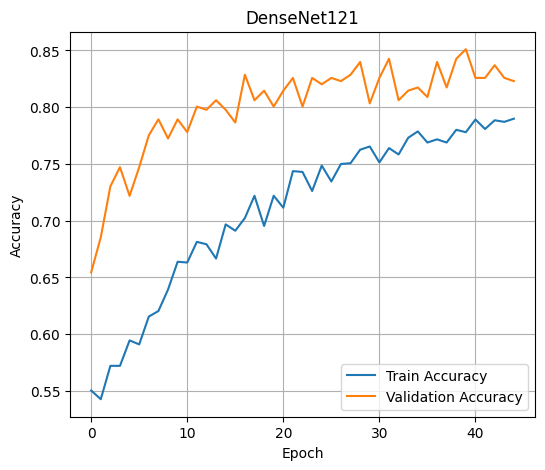

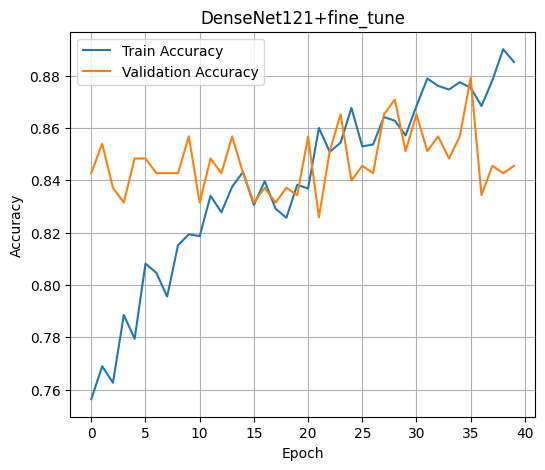

In [ ]:
import matplotlib.pyplot as plt

def plot_accuracy_only(history, model_name="DenseNet121"):
    plt.figure(figsize=(6, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_accuracy_only(history, "DenseNet121")
plot_accuracy_only(fine_tune_history, "DenseNet121+fine_tune")



In [ ]:
  #predict on validation set
y_pred = model.predict(val_aug)  # val_pl is your validation ImageDataGenerator
y_pred = (y_pred > 0.5).astype(int)  # convert sigmoid probabilities to binary class (0 or 1)
y_true = val_aug.classes  # true labels from the generator

# Вывод Accuracy, F1 и др.
acc1, f1_1, _, _ = evaluate_classification_metrics(y_true, y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step
✅ Accuracy: 0.8427
🎯 F1-score: 0.8418
🔍 Precision: 0.8466
📥 Recall: 0.8371
